# Iowa Seasonal Risk Hours

This notebook isolates Steps 4–5 of the state planning analysis. It counts individual hourly observations—not grouped events—for six fixed-capacity portfolios, five 20-year periods, four Iowa-local seasons, and two stress metrics.

## Inputs and definitions

In [1]:
from pathlib import Path
from zoneinfo import ZoneInfo

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

DATA_ROOT = Path("../../data")
OUTPUT_DIR = Path("../../notebook_outputs/analysis/state_seasonal_risk_hours")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

STATE_ABBR = "IA"
TAIESM_DATASET = "taiesm1_historical_ssp245_v022_2000_2099"
METRICS_PATH = DATA_ROOT / TAIESM_DATASET / "state_scenario_metrics" / f"{STATE_ABBR}_{TAIESM_DATASET}_scenario_metrics.parquet"

SCENARIOS = pd.DataFrame([
    ("installed_2024", "2024 EIA-860 Operable"),
    ("split_w100_s00", "100W / 0S"),
    ("split_w75_s25", "75W / 25S"),
    ("split_w50_s50", "50W / 50S"),
    ("split_w25_s75", "25W / 75S"),
    ("split_w00_s100", "0W / 100S"),
], columns=["scenario", "scenario_label"])

PLANNING_PERIODS = pd.DataFrame([
    ("2000_2019", 2000, 2019),
    ("2020_2039", 2020, 2039),
    ("2040_2059", 2040, 2059),
    ("2060_2079", 2060, 2079),
    ("2080_2099", 2080, 2099),
], columns=["planning_period", "start_year", "end_year"])

SEASON_ORDER = ["Dec/Jan/Feb", "Mar/Apr/May", "Jun/Jul/Aug", "Sep/Oct/Nov"]
SEASON_LABELS = {
    "Dec/Jan/Feb": "DJF (Winter)", "Mar/Apr/May": "MAM (Spring)",
    "Jun/Jul/Aug": "JJA (Summer)", "Sep/Oct/Nov": "SON (Autumn)",
}
SEASON_COLORS = {
    "Dec/Jan/Feb": "tab:blue", "Mar/Apr/May": "tab:orange",
    "Jun/Jul/Aug": "tab:green", "Sep/Oct/Nov": "tab:red",
}
MONTH_TO_SEASON = {
    12: "Dec/Jan/Feb", 1: "Dec/Jan/Feb", 2: "Dec/Jan/Feb",
    3: "Mar/Apr/May", 4: "Mar/Apr/May", 5: "Mar/Apr/May",
    6: "Jun/Jul/Aug", 7: "Jun/Jul/Aug", 8: "Jun/Jul/Aug",
    9: "Sep/Oct/Nov", 10: "Sep/Oct/Nov", 11: "Sep/Oct/Nov",
}
PERIOD_ORDER = PLANNING_PERIODS["planning_period"].tolist()
assert METRICS_PATH.is_file()

## Step 4: Summarize direct hourly stress

The net-load threshold is the P95 computed from all hours in all six mixes over 2000–2099. The renewable threshold is an absolute equivalent CF of 10%. Conditions are inclusive.

In [2]:
NET_LOAD_STRESS_QUANTILE = 0.95
RENEWABLE_CF_STRESS_THRESHOLD = 0.10
STRESS_METRICS = pd.DataFrame([
    ("net_load_p95", "Net load at or above pooled P95"),
    ("renew_cf_10pct", "Renewable-equivalent CF at or below 10%"),
], columns=["stress_metric", "stress_metric_label"])

hourly = pd.read_parquet(
    METRICS_PATH,
    columns=["time_utc", "scenario", "net_load_mw__raw", "renew_cf_equiv"],
)
hourly["time_utc"] = pd.to_datetime(hourly["time_utc"], utc=True)
scenario_hours = hourly.groupby("scenario").size()
assert set(scenario_hours.index) == set(SCENARIOS["scenario"])
assert scenario_hours.eq(100 * 8760).all()
assert not hourly.duplicated(["scenario", "time_utc"]).any()
assert not hourly[["net_load_mw__raw", "renew_cf_equiv"]].isna().any().any()

net_load_p95_mw = float(hourly["net_load_mw__raw"].quantile(NET_LOAD_STRESS_QUANTILE))
hourly["planning_period"] = pd.NA
for period in PLANNING_PERIODS.itertuples(index=False):
    mask = hourly["time_utc"].dt.year.between(period.start_year, period.end_year)
    hourly.loc[mask, "planning_period"] = period.planning_period

local_time = hourly["time_utc"].dt.tz_convert(ZoneInfo("America/Chicago"))
hourly["season"] = local_time.dt.month.map(MONTH_TO_SEASON).to_numpy()
assert not hourly[["planning_period", "season"]].isna().any().any()

masks = {
    "net_load_p95": hourly["net_load_mw__raw"].ge(net_load_p95_mw),
    "renew_cf_10pct": hourly["renew_cf_equiv"].le(RENEWABLE_CF_STRESS_THRESHOLD),
}
rows = []
direct_totals = {}
for metric, mask in masks.items():
    direct_totals[metric] = int(mask.sum())
    grouped = hourly.loc[mask].groupby(["scenario", "planning_period", "season"], as_index=False).size()
    grouped = grouped.rename(columns={"size": "stress_hours"})
    grouped["stress_metric"] = metric
    rows.append(grouped)

complete_index = pd.MultiIndex.from_product(
    [SCENARIOS["scenario"], STRESS_METRICS["stress_metric"], PERIOD_ORDER, SEASON_ORDER],
    names=["scenario", "stress_metric", "planning_period", "season"],
)
summary = (
    pd.concat(rows, ignore_index=True)
    .set_index(["scenario", "stress_metric", "planning_period", "season"])["stress_hours"]
    .reindex(complete_index, fill_value=0).astype("int64").rename("stress_hours").reset_index()
    .merge(SCENARIOS, on="scenario", validate="many_to_one")
    .merge(STRESS_METRICS, on="stress_metric", validate="many_to_one")
)
summary = summary[["scenario", "scenario_label", "stress_metric", "stress_metric_label", "planning_period", "season", "stress_hours"]]
assert len(summary) == 6 * 5 * 4 * 2 == 240
for metric, total in direct_totals.items():
    assert int(summary.loc[summary["stress_metric"].eq(metric), "stress_hours"].sum()) == total

summary.to_csv(OUTPUT_DIR / "iowa_seasonal_risk_hours.csv", index=False)
thresholds = pd.DataFrame([
    {"metric": "net_load_p95", "condition": f"net_load_mw__raw >= {net_load_p95_mw:.6f} MW", "basis": "All mixes, all 2000–2099 hours"},
    {"metric": "renew_cf_10pct", "condition": "renew_cf_equiv <= 0.10", "basis": "Absolute equivalent capacity factor"},
])
display(thresholds)
print(f"Created {len(summary)} rows: 6 portfolios × 5 periods × 4 seasons × 2 metrics.")
display(summary.head(12))
del hourly

,metric,condition,basis
0,net_load_p95,net_load_mw__raw >= 6011.157414 MW,"All mixes, all 2000–2099 hours"
1,renew_cf_10pct,renew_cf_equiv <= 0.10,Absolute equivalent capacity factor


Created 240 rows: 6 portfolios × 5 periods × 4 seasons × 2 metrics.


,scenario,scenario_label,stress_metric,stress_metric_label,planning_period,season,stress_hours
0,installed_2024,2024 EIA-860 Operable,net_load_p95,Net load at or above pooled P95,2000_2019,Dec/Jan/Feb,1478
1,installed_2024,2024 EIA-860 Operable,net_load_p95,Net load at or above pooled P95,2000_2019,Mar/Apr/May,118
2,installed_2024,2024 EIA-860 Operable,net_load_p95,Net load at or above pooled P95,2000_2019,Jun/Jul/Aug,3160
3,installed_2024,2024 EIA-860 Operable,net_load_p95,Net load at or above pooled P95,2000_2019,Sep/Oct/Nov,211
4,installed_2024,2024 EIA-860 Operable,net_load_p95,Net load at or above pooled P95,2020_2039,Dec/Jan/Feb,1033
5,installed_2024,2024 EIA-860 Operable,net_load_p95,Net load at or above pooled P95,2020_2039,Mar/Apr/May,62
6,installed_2024,2024 EIA-860 Operable,net_load_p95,Net load at or above pooled P95,2020_2039,Jun/Jul/Aug,3945
7,installed_2024,2024 EIA-860 Operable,net_load_p95,Net load at or above pooled P95,2020_2039,Sep/Oct/Nov,458
8,installed_2024,2024 EIA-860 Operable,net_load_p95,Net load at or above pooled P95,2040_2059,Dec/Jan/Feb,909
9,installed_2024,2024 EIA-860 Operable,net_load_p95,Net load at or above pooled P95,2040_2059,Mar/Apr/May,27


## Step 5: Plot seasonal risk hours

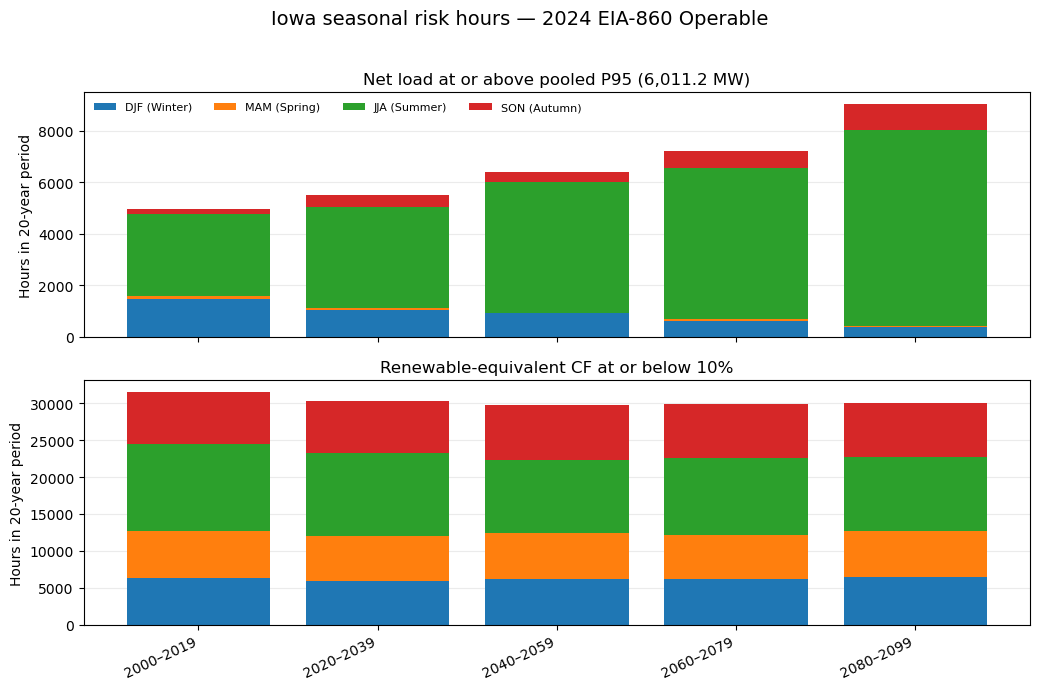

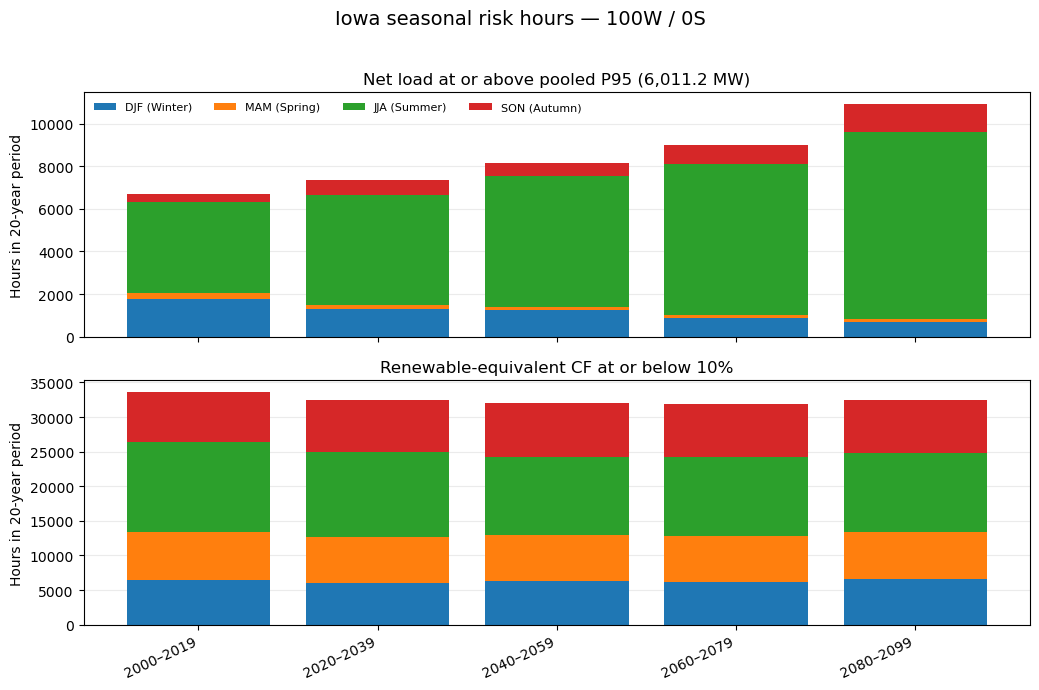

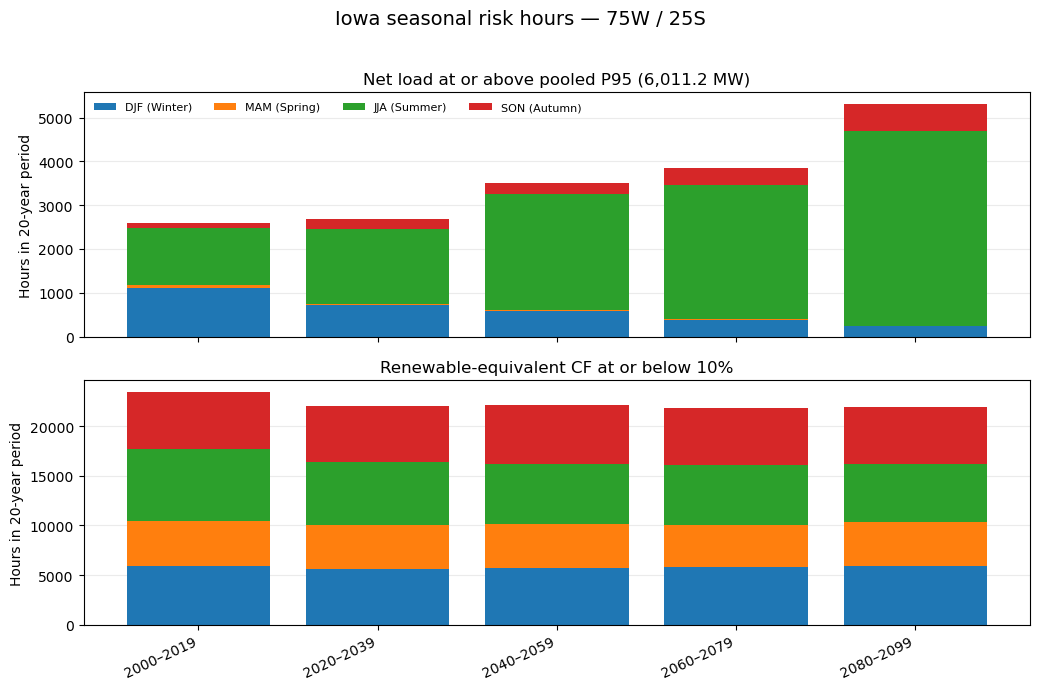

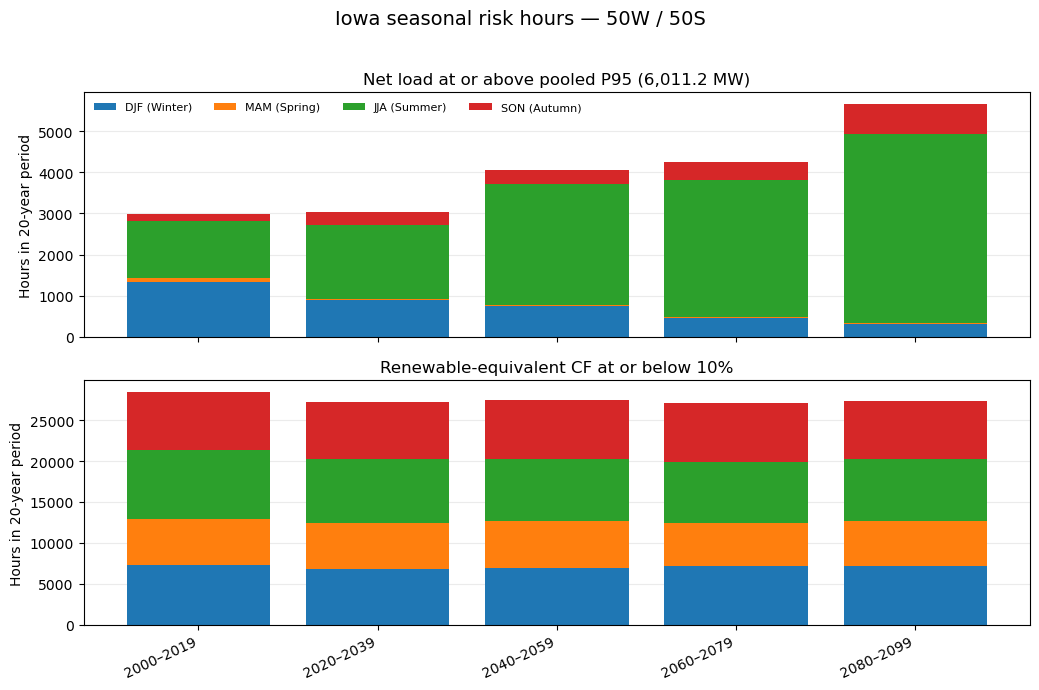

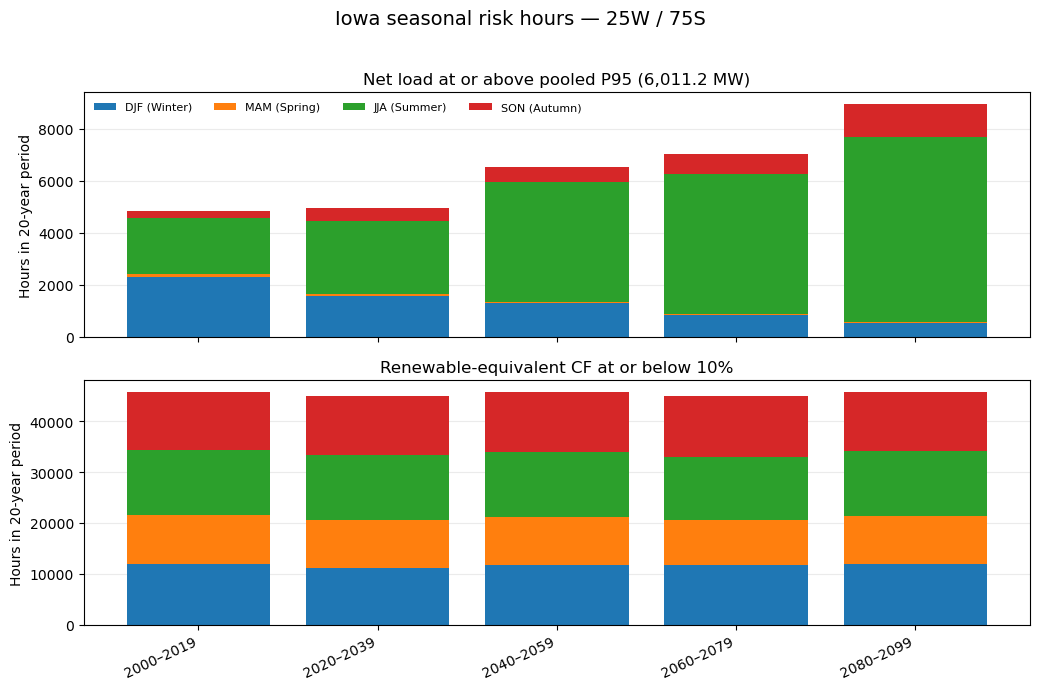

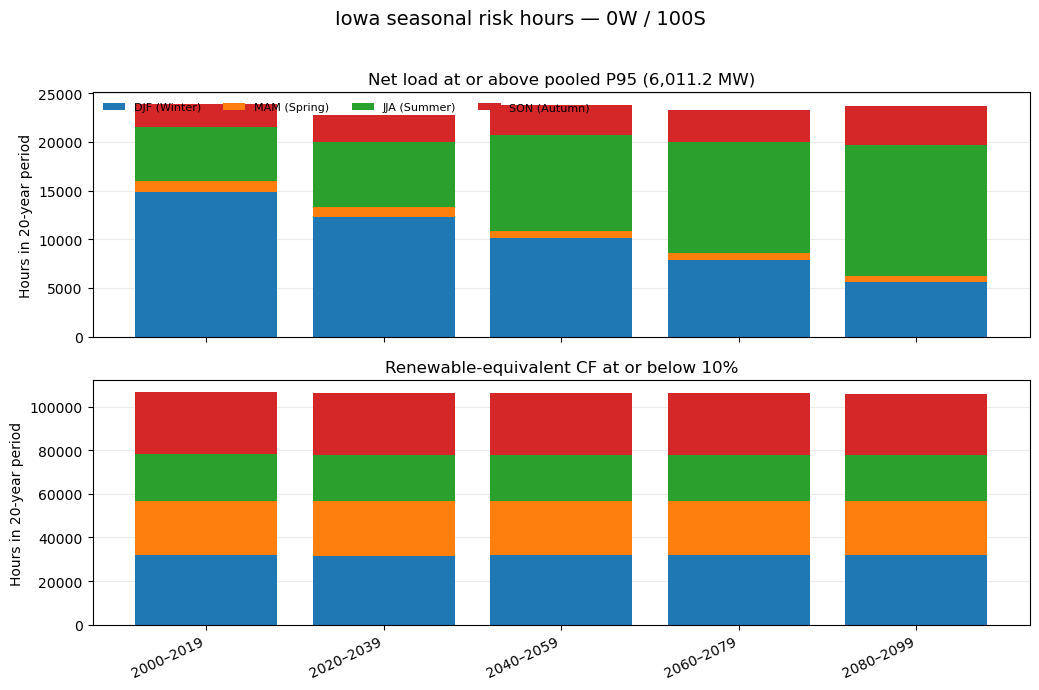

Saved 6 portfolio figures in outputs\state_seasonal_risk_hours.


In [3]:
titles = {
    "net_load_p95": f"Net load at or above pooled P95 ({net_load_p95_mw:,.1f} MW)",
    "renew_cf_10pct": "Renewable-equivalent CF at or below 10%",
}
x = np.arange(len(PERIOD_ORDER))
period_labels = [period.replace("_", "–") for period in PERIOD_ORDER]
plot_paths = []

for scenario in SCENARIOS.itertuples(index=False):
    scenario_rows = summary[summary["scenario"].eq(scenario.scenario)]
    fig, axes = plt.subplots(2, 1, figsize=(10.5, 7.0), sharex=True)
    for axis, metric in zip(axes, STRESS_METRICS["stress_metric"]):
        matrix = scenario_rows[scenario_rows["stress_metric"].eq(metric)].pivot(
            index="planning_period", columns="season", values="stress_hours"
        ).reindex(index=PERIOD_ORDER, columns=SEASON_ORDER, fill_value=0)
        assert matrix.shape == (5, 4) and not matrix.isna().any().any()
        bottom = np.zeros(5)
        for season in SEASON_ORDER:
            values = matrix[season].to_numpy(dtype=float)
            axis.bar(x, values, bottom=bottom, color=SEASON_COLORS[season], label=SEASON_LABELS[season])
            bottom += values
        axis.set_title(titles[metric])
        axis.set_ylabel("Hours in 20-year period")
        axis.grid(axis="y", alpha=0.25)
        axis.set_axisbelow(True)
    axes[-1].set_xticks(x, period_labels, rotation=25, ha="right")
    axes[0].legend(frameon=False, ncol=4, fontsize=8, loc="upper left")
    fig.suptitle(f"Iowa seasonal risk hours — {scenario.scenario_label}", fontsize=14)
    fig.tight_layout(rect=(0, 0, 1, 0.96))
    output_path = OUTPUT_DIR / f"iowa_{scenario.scenario}_seasonal_risk_hours.png"
    fig.savefig(output_path, dpi=180, bbox_inches="tight")
    plot_paths.append(output_path)
    plt.show()
    plt.close(fig)

assert len(plot_paths) == 6 and all(path.stat().st_size > 0 for path in plot_paths)
print(f"Saved {len(plot_paths)} portfolio figures in {OUTPUT_DIR}.")